# GZD-5 Classfication
___

## Setup

### Importing Packages

In [1]:
%matplotlib widget

import os
import shutil
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from astronomaly.dimensionality_reduction import pca
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from umap import UMAP
from projectFunctions import myBGMM, myMBKM, create_gz_evaluation_set, saving_images, distance_bin_plots, confidence_bin_plots

### Directories

In [2]:
# Data Root Directory
data_root_dir = os.path.join(os.getcwd(), 'Data')

# Image Directory
img_dir = os.path.join(data_root_dir, 'Images')

# Label Directory
label_dir = os.path.join(data_root_dir, 'gz_decals_volunteers_5.parquet')

# Feature Directory
feature_dir = os.path.join(data_root_dir, 'GalaxyZoo_Main_Features.parquet')

### Feature Space

#### Loading Feature Data

In [3]:
features = pd.read_parquet(feature_dir)
print('Features: ', features.shape)

Features:  (230575, 512)


#### PCA

In [4]:
my_pca = pca.PCA_Decomposer(force_rerun=True, n_components=29, threshold=0.95, output_dir=data_root_dir)
pca_features = my_pca.run(features)
pca_features.to_parquet(os.path.join(data_root_dir, 'pca_features.parquet'))
print('PCA Features: ', pca_features.shape)
print(type(pca_features))

Running PCA_Decomposer ...
Total explained variance: 0.9516112676479792
Done! Time taken: 1.1975247859954834 s
PCA Features:  (230575, 29)
<class 'pandas.core.frame.DataFrame'>


### Volunteer Labels

#### Loading Label Data

In [5]:
full_volunteer_labels = pd.read_parquet(label_dir)
full_volunteer_labels = full_volunteer_labels.set_index('iauname')
print('Full GZD-5 Volunteer Labels: ', full_volunteer_labels.shape)
full_volunteer_labels = full_volunteer_labels[~full_volunteer_labels['wrong_size_warning']]
print('wrong_size_warning filtered GZD-5 Volunteer Labels: ', full_volunteer_labels.shape)
print('columns: ', full_volunteer_labels.columns)

Full GZD-5 Volunteer Labels:  (253286, 126)
wrong_size_warning filtered GZD-5 Volunteer Labels:  (250930, 126)
columns:  Index(['ra', 'dec', 'redshift', 'elpetro_absmag_r', 'sersic_nmgy_r',
       'petro_th50', 'petro_th90', 'petro_theta', 'upload_group',
       'active_learning_on',
       ...
       'merging_minor-disturbance_fraction',
       'merging_minor-disturbance_debiased', 'merging_major-disturbance',
       'merging_major-disturbance_fraction',
       'merging_major-disturbance_debiased', 'merging_merger',
       'merging_merger_fraction', 'merging_merger_debiased',
       'wrong_size_statistic', 'wrong_size_warning'],
      dtype='object', length=126)


#### Refining Volunteer Labels

In [6]:
my_label_df, summ = create_gz_evaluation_set(full_volunteer_labels, 
                                             question_level=3, min_votes=34, max_votes=None, half_votes_min=True, min_prob=0, max_prob=1, min_sources=100)
print('Refined GZD-5 Evaluation Set: ', my_label_df.shape)

Refined GZD-5 Evaluation Set:  (47153, 5)


#### Confidently Labeled [Elliptical, Spiral, Edge On]

Labelled Galaxies:  (24858, 127)
Round Ellipticals:  9464
Spirals:  12432
Edge-ons:  2962


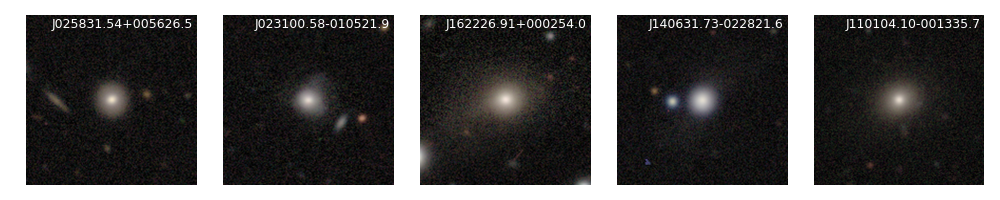

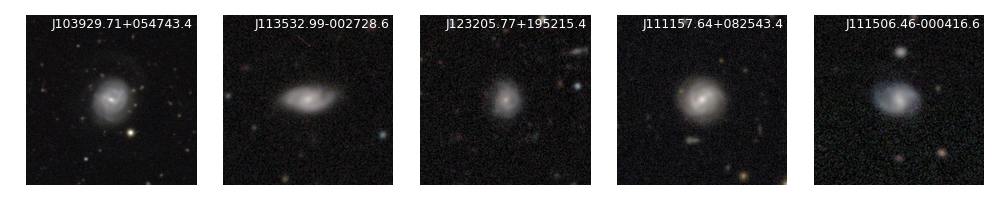

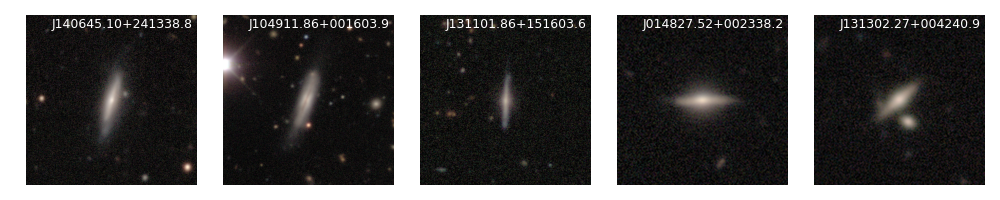

In [7]:
ellipticals = my_label_df[(my_label_df['smooth-or-featured'] == 'smooth-or-featured_smooth') & 
                          (my_label_df['merging'] == 'merging_none') & 
                          (my_label_df['how-rounded'] == 'how-rounded_round')].index
spirals = my_label_df[(my_label_df['smooth-or-featured'] == 'smooth-or-featured_featured-or-disk') & 
                      (my_label_df['merging'] == 'merging_none') &
                      (my_label_df['disk-edge-on'] == 'disk-edge-on_no')].index
edge_ons = my_label_df[(my_label_df['smooth-or-featured'] == 'smooth-or-featured_featured-or-disk') & 
                       (my_label_df['merging'] == 'merging_none') &
                       (my_label_df['disk-edge-on'] == 'disk-edge-on_yes')].index

saving_images(ellipticals, 'elliptical', img_dir, data_root_dir)
saving_images(spirals, 'spiral', img_dir, data_root_dir)
saving_images(edge_ons, 'edge_on', img_dir, data_root_dir)

# Combining the indices of the three classes to create a single DataFrame of volunteer labels
volunteer_labels_indices = ellipticals.union(spirals).union(edge_ons)
# Filtering the full volunteer labels to only include the galaxies that belong to the three classes
volunteer_labels = full_volunteer_labels.loc[volunteer_labels_indices]
# Assigning class labels to the volunteer labels DataFrame
volunteer_labels.loc[ellipticals, 'Volunteer_Label'] = 'R'   # Round ellipticals
volunteer_labels.loc[spirals, 'Volunteer_Label'] = 'S'       # Spirals
volunteer_labels.loc[edge_ons, 'Volunteer_Label'] = 'E'      # Edge-ons

print('Labelled Galaxies: ', volunteer_labels.shape)
print('Round Ellipticals: ',    (volunteer_labels['Volunteer_Label'] == 'R').sum())
print('Spirals: ',              (volunteer_labels['Volunteer_Label'] == 'S').sum())
print('Edge-ons: ',             (volunteer_labels['Volunteer_Label'] == 'E').sum())

## Clustering

In [8]:
method = 'MBKM'
no_of_runs = 1

#no_of_clusters_to_test = np.arange(1,41,1)
no_of_clusters_to_test = np.array([20])

In [9]:
avg_accuracies = np.zeros(len(no_of_clusters_to_test))

print(f"Avg. Accuracy after {no_of_runs} Runs")

for j in range(len(no_of_clusters_to_test)):
    no_of_clusters = no_of_clusters_to_test[j]
    total_accuracies = np.zeros(no_of_runs)

    

    for i in range(no_of_runs):

        if method == 'MBKM':
            clusters = myMBKM(pca_features, n_clusters=no_of_clusters, max_iter=10, n_init=10)
        elif method == 'BGMM':
            clusters = myBGMM(pca_features, n_components=no_of_clusters, weight_concentration_prior=0.5, n_init=10, max_iter=1000)
        #print(f'{method} Clusters: ', clusters.shape)

        # PREDICTING FROM MODAL TEST SUBSET
        ####################################
        # Merging the cluster assignments with the confident labels
        test_subset = clusters.merge(volunteer_labels, left_index=True, right_index=True, how='inner')
        test_subset.to_parquet(os.path.join(data_root_dir, f'{method}_test_subset.parquet'))

        #print('Labelled and Clustered Galaxies: ', test_subset.shape)
        #print('Round Ellipticals: ',    (test_subset['Volunteer_Label'] == 'R').sum())
        #print('Spirals: ',              (test_subset['Volunteer_Label'] == 'S').sum())
        #print('Edge-ons: ',             (test_subset['Volunteer_Label'] == 'E').sum())

        # Group by Cluster and Type to find how many of each type in each cluster
        counts = test_subset.groupby(['Cluster', 'Volunteer_Label']).size()
        counts_df = counts.reset_index(name='Count')
        # Add Total and Percentage Accuracy Columns
        counts_df['Total'] = counts_df.groupby('Cluster')['Count'].transform('sum')
        counts_df['Percentage'] = counts_df['Count'] / counts_df['Total'] * 100
        #print(counts_df.head(n=20))

        # Find Dominant Type in Each Cluster
        dominant = counts_df.loc[counts_df.groupby('Cluster')['Count'].idxmax()]
        # Save Summary Array
        summary_df = dominant.set_index('Cluster')[['Volunteer_Label', 'Percentage']]
        summary_df.columns = ['Dominant_Type', 'Percentage']
        #print(summary_df)

        # Map the dominant type to each galaxy in the test subset based on its cluster assignment
        test_subset['Predicted_Label'] = test_subset['Cluster'].map(summary_df['Dominant_Type'])

        # EVALUATION METRICS
        ######################
        accuracy = accuracy_score(test_subset['Volunteer_Label'], test_subset['Predicted_Label'])
        total_accuracies[i] = accuracy
        #R_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'R']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'R']['Predicted_Label']) 
        #S_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'S']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'S']['Predicted_Label']) 
        #E_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'E']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'E']['Predicted_Label']) 
        
        #print(f'Overall Accuracy: {accuracy:.2f}')
        #print('Class Accuracy\n##############')
        #print(f'R: {R_accuracy:.2f}')
        #print(f'S: {S_accuracy:.2f}')
        #print(f'E: {E_accuracy:.2f}')
        #print('\nClassification Report\n#####################')
        #print(classification_report(test_subset['Volunteer_Label'], test_subset['Predicted_Label'], labels=['R', 'S', 'E']))

    avg_accuracies[j] = total_accuracies.sum()/total_accuracies.size
    print(f"{no_of_clusters} Clusters: {avg_accuracies[j]:.2f}")

Avg. Accuracy after 1 Runs
20 Clusters: 0.73


## Plots

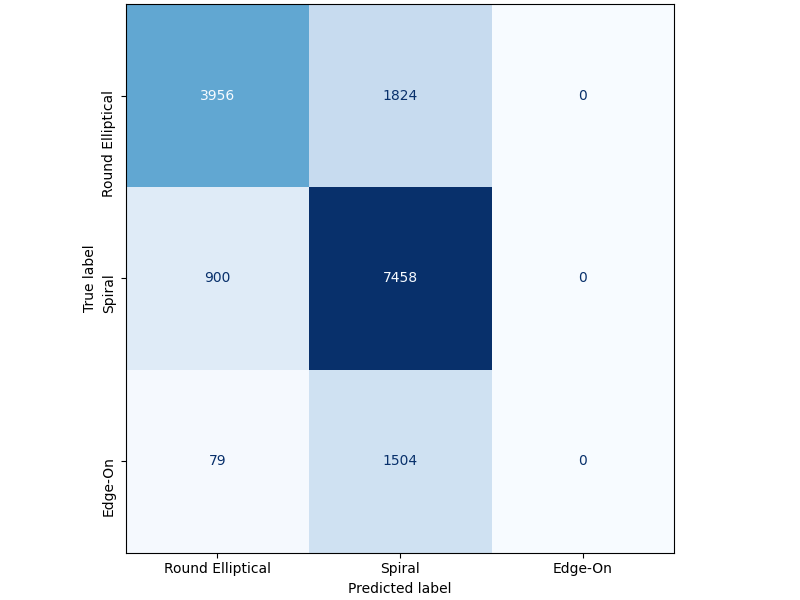

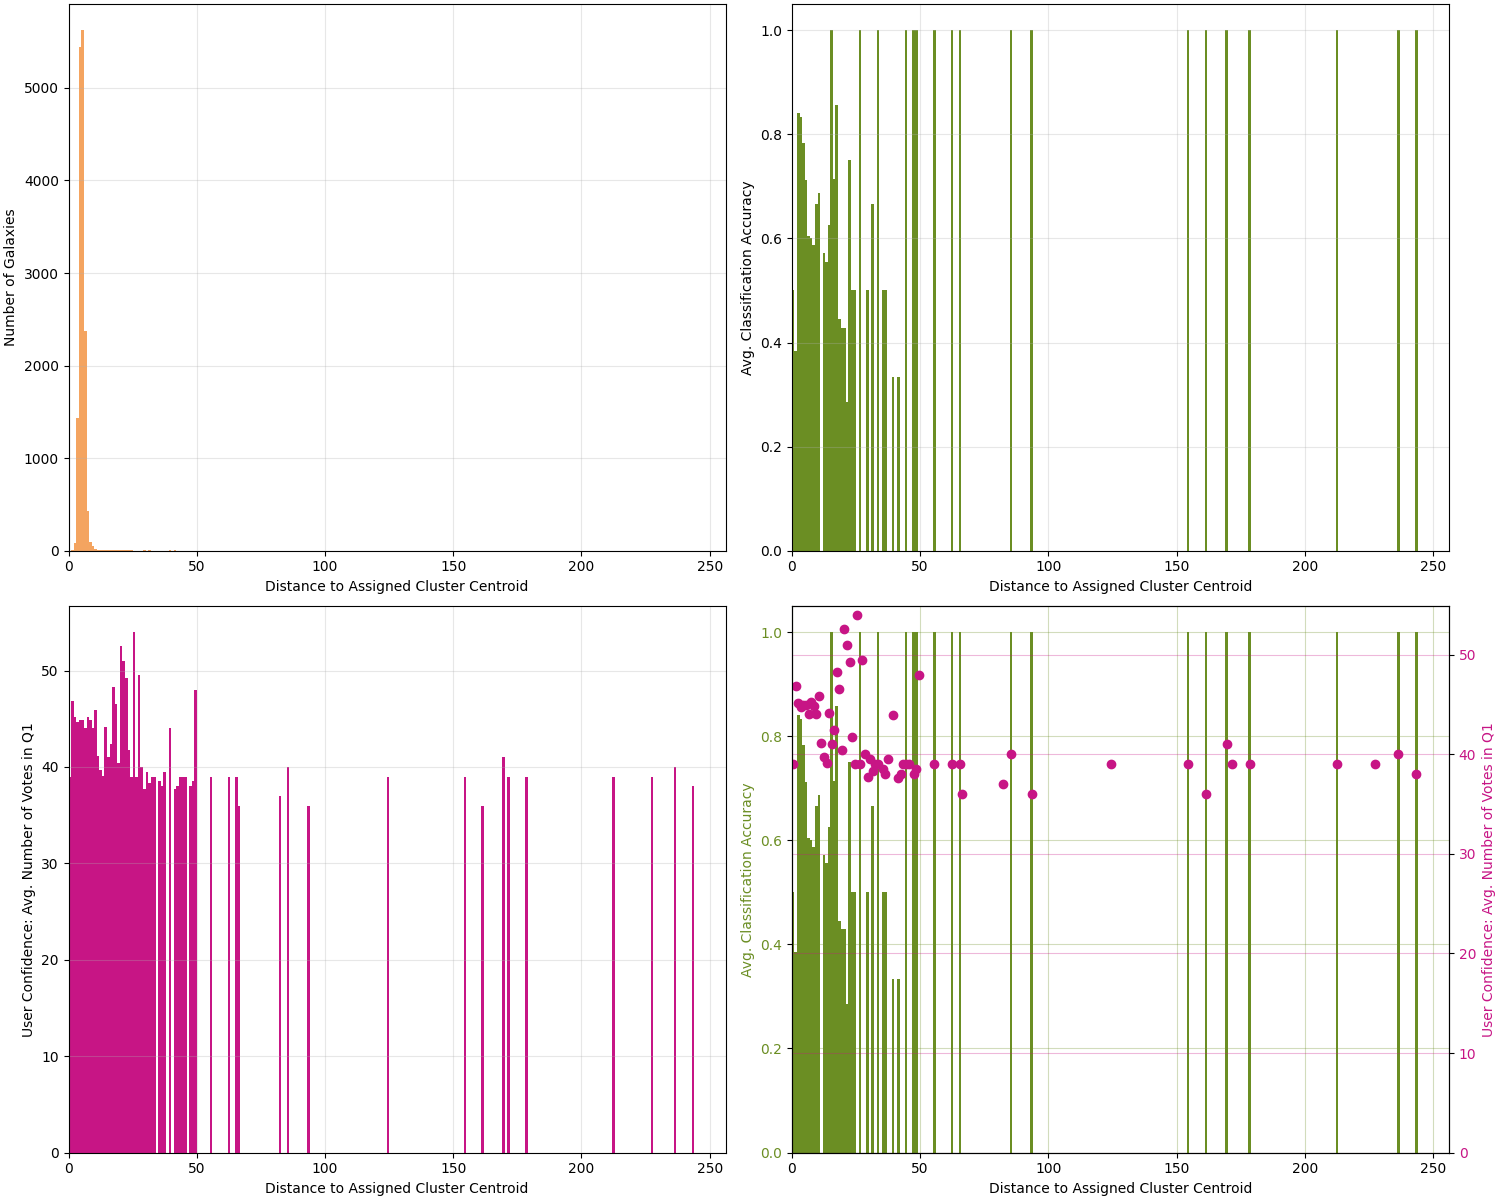

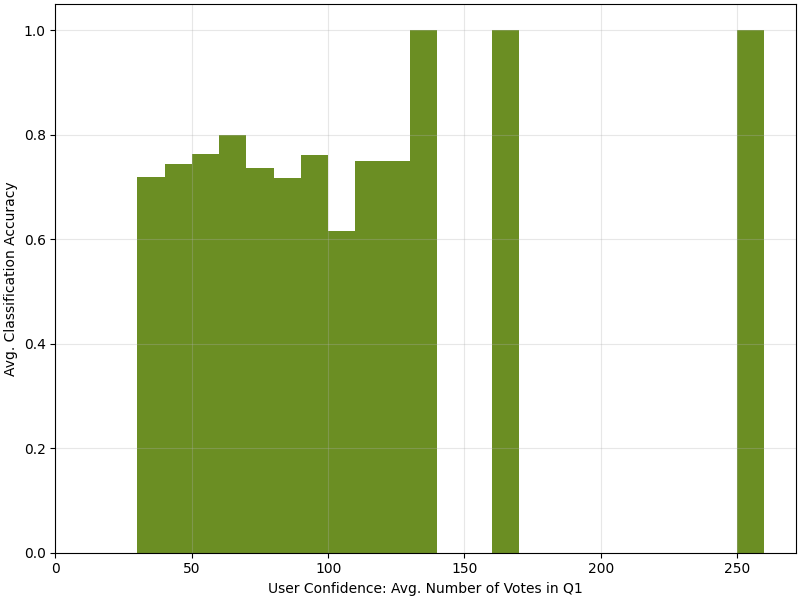

In [11]:
# Plotting the Confusion Matrix
_, ax1 = plt.subplots(1,1,figsize=(8,6), constrained_layout=True)
cm = confusion_matrix(test_subset['Volunteer_Label'], test_subset['Predicted_Label'], labels=['R', 'S', 'E'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Round Elliptical', 'Spiral', 'Edge-On'], )
disp.plot(ax=ax1, colorbar=False ,cmap=plt.cm.Blues)
ax1.tick_params(axis="y", rotation=90)
plt.savefig(os.path.join('Data/Thesis Plots', f'{method}_confusion_matrix.png'), bbox_inches='tight')
plt.show()

distance_bin_plots(test_subset, n_clusters=no_of_clusters, xlimits=None, ylimits=None, method=method)
confidence_bin_plots(test_subset, width=10, xlimits=None, ylimits=None, method=method)

In [ ]:
from scipy.optimize import curve_fit 

def f_x(x, A, B, C):
    return A - B*np.exp(-C*x)

popt, pcov = curve_fit(f_x, no_of_clusters_to_test, avg_accuracies)
a,b,c = popt
print(a)

plt.scatter(no_of_clusters_to_test, avg_accuracies)
plt.plot(no_of_clusters_to_test, f_x(no_of_clusters_to_test, a, b, c), label='Exponential Fit')
plt.xlabel("No. of Clusters")
plt.ylabel(f"Avg. Classification Accuracy over {no_of_runs} Runs")
plt.grid()
plt.legend()
plt.show()

## UMAP Clustering Analysis

In [ ]:
clusters["Dominant_Type"] = clusters["Cluster"].map(summary_df["Dominant_Type"])

In [ ]:
umap = UMAP(n_components=2, random_state=20)
umap_features = umap.fit_transform(pca_features)

### Full Feature Space

#### Coloured by Cluster

In [ ]:
clusters_integers = clusters["Cluster"].astype(int)

cmap = plt.get_cmap("tab20", no_of_clusters)
norm = mcolors.BoundaryNorm(np.arange(-0.5, no_of_clusters+0.5, 1), cmap.N)

fig, ax = plt.subplots(figsize=(10, 8))

sc = plt.scatter(umap_features[:, 0], umap_features[:, 1], c=clusters_integers, cmap=cmap, s=2, norm=norm, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(no_of_clusters))
cbar.set_label('Cluster')
plt.clim(-0.5, no_of_clusters-0.5)

if method == 'MBKM':
    plt.title('Full MBKM Feature Space UMAP: Colored by Cluster')
elif method == 'BGMM':
    plt.title('Full BGMM Feature Space UMAP: Colored by Cluster')
plt.xticks([])
plt.yticks([]) 
plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Full_{method}_Feature_Space_UMAP_Colored_by_Cluster.png'), dpi=300, bbox_inches='tight')
plt.show()

#### Coloured by Type

In [ ]:
class_order = ['R', 'S', 'E']
class_to_int = {label: i for i, label in enumerate(class_order)}

type_colours = ["#9467bd", '#ffbb78', "#17becf"]
cmap_type = ListedColormap(type_colours)
norm_type = mcolors.BoundaryNorm(np.arange(-0.5, len(class_order)+0.5, 1),cmap_type.N)

type_ints = clusters['Dominant_Type'].map(class_to_int)

plt.figure(figsize=(10, 8))

sc = plt.scatter(umap_features[:,0],umap_features[:,1],c=type_ints,cmap=cmap_type,norm=norm_type,s=2, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(len(class_order)))
cbar.set_ticklabels(class_order)
cbar.set_label('Predicted Morphological Label')

if method == 'MBKM':
    plt.title('Full MBKM Feature Space UMAP: Colored by Predicted Type')
elif method == 'BGMM':
    plt.title('Full BGMM Feature Space UMAP: Colored by Predicted Type')
plt.xticks([])
plt.yticks([]) 
plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Full_{method}_Feature_Space_UMAP_Colored_by_Predicted_Type.png'), dpi=300, bbox_inches='tight')
plt.show()

### Test Set on Feature Space

In [ ]:
mask = pca_features.index.isin(test_subset.index)

#### Coloured by Cluster

In [ ]:
colors = plt.cm.tab20.colors
cmap = ListedColormap(colors[:no_of_clusters])
cluster_labels, cluster_ints = np.unique(test_subset['Cluster'], return_inverse=True)

plt.figure(figsize=(10, 8))

plt.scatter(umap_features[~mask, 0], umap_features[~mask, 1], c='lightgrey', s=2, label='Unlabelled')
sc = plt.scatter(umap_features[mask, 0], umap_features[mask, 1], c=cluster_ints, cmap=cmap, s=2, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(len(cluster_labels)))
cbar.set_label('Cluster')
cbar.set_ticks(np.arange(len(cluster_labels)))
cbar.set_ticklabels(cluster_labels)
plt.clim(-0.5, len(cluster_labels)-0.5)

if method == 'MBKM':
    plt.title('Test Set MBKM Feature Space UMAP: Colored by Cluster')
elif method == 'BGMM':
    plt.title('Test Set BGMM Feature Space UMAP: Colored by Cluster')
plt.xticks([])
plt.yticks([])  
plt.legend()
plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Test_Set_{method}_Feature_Space_UMAP_Colored_by_Cluster.png'), dpi=300, bbox_inches='tight')
plt.show()

#### Coloured by Type

In [ ]:
type_ints = test_subset['Volunteer_Label'].map(class_to_int)

plt.figure(figsize=(10, 8))

plt.scatter(umap_features[~mask, 0], umap_features[~mask, 1], c='lightgrey', s=2, label='Unlabelled')
sc = plt.scatter(umap_features[mask, 0], umap_features[mask, 1], c=type_ints, cmap=cmap_type, norm=norm_type, s=2, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(len(class_order)))
cbar.set_ticklabels(class_order)
cbar.set_label('Volunteer Label')

if method == 'MBKM':
    plt.title('Test Set MBKM Feature Space UMAP: Colored by Volunteer Label')
elif method == 'BGMM':
    plt.title('Test Set BGMM Feature Space UMAP: Colored by Volunteer Label')
plt.xticks([])
plt.yticks([]) 
plt.legend()
plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Test_Set_{method}_Feature_Space_UMAP_Colored_by_Volunteer_Label.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
correct = (test_subset['Volunteer_Label'] == test_subset['Predicted_Label']).to_numpy()

plt.figure(figsize=(8, 8))

plt.scatter(umap_features[~mask, 0],umap_features[~mask, 1],c='lightgrey',s=2)
plt.scatter(umap_features[mask][~correct, 0],umap_features[mask][~correct, 1],c='salmon',s=2,label='Incorrect', alpha=0.5)

if method == 'MBKM':
    plt.title('Test Set MBKM Feature Space UMAP: Colored by Accuracy of Predicted Label')
elif method == 'BGMM':
    plt.title('Test Set BGMM Feature Space UMAP: Colored by Accuracy of Predicted Label')
plt.xticks([])
plt.yticks([]) 
plt.legend()
plt.show()

## Interactive UMAP (Test Set on Feature Space)

In [ ]:
from IPython.display import display
%matplotlib widget

um_feats = pd.DataFrame(umap_features, index=pca_features.index, columns=['0', '1'])
um_feats = um_feats[mask]
x = um_feats['0'].values
y = um_feats['1'].values
labels = um_feats.index.to_numpy()
plt.close('all')
fig, ax = plt.subplots(figsize=(5,5))
sc = ax.scatter(x, y, c='k', alpha=0.1, s=1)

clicked = [] # keep track of selected indices

def on_click(event):
    if event.inaxes != ax:
        return
    click_x, click_y = event.xdata, event.ydata
    dist = np.hypot(x - click_x, y - click_y)
    i = np.argmin(dist)

    msg = f"Index: {labels[i]} (x={x[i]}, y={y[i]})"
    clicked.append(labels[i])

    # this makes sure it shows in Jupyter output
    display(msg)

    # mark and label point on plot
    ax.plot(x[i], y[i], 'ro', markersize=1)
    ax.annotate(labels[i], (x[i], y[i]), textcoords="offset points", xytext=(5,5), fontsize=2, color="red")
    fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()

#### Plotting Selected Galaxies

In [ ]:
plt.close('all')
%matplotlib inline
clicked = np.array(clicked)
filenames_to_find = set(clicked.astype(str) + '.png')

# collect paths of images to display
img_paths = []
for root, dirs, files in os.walk(img_dir):
    for file in files:
        if file in filenames_to_find:
            img_paths.append(os.path.join(root, file))

# display images in a grid
n_cols = 5  # number of columns in the grid
n_rows = (len(img_paths) + n_cols - 1) // n_cols  # compute rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()  # flatten in case of multiple rows

for ax, img_path in zip(axes, img_paths):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')  # hide axes
    ax.set_title(os.path.basename(img_path), fontsize=8)

# hide any unused axes
for ax in axes[len(img_paths):]:
    ax.axis('off')

plt.suptitle('Selected Galaxy Images', fontsize=16)
plt.tight_layout()
plt.show()